## Retail Store Dashboard - Python & SQL

### Install all related libraries like
1. import kaggle
2. import numpy as np
3. import pandas as pd
4. import matplotlip.pyplot as plt
5. import seaborn as sns

In [1]:
# Import kaggle

import kaggle

### Downloading the required file from Kaggle website using Kaggle API call

In [2]:
kaggle.api.authenticate()

# Download the dataset

!kaggle datasets download -d ankitbansal06/retail-orders

Dataset URL: https://www.kaggle.com/datasets/ankitbansal06/retail-orders
License(s): CC0-1.0
retail-orders.zip: Skipping, found more recently modified local copy (use --force to force download)


### Now the Dataset is finally downloaded from the Kaggle website but it is in .zip form we need to extract it

In [3]:
# Extracting the dataset from the zip file

import zipfile
with zipfile.ZipFile('retail-orders.zip', 'r') as zip_ref:
    zip_ref.extractall('retail-orders')
zip_ref.close()

### Now the dataset is extracted and we are going to install the neccessary libraries for performing data cleaning process and for visualizations like:

#### Libraries are:
1. NumPy
2. Pandas
3. Matplotlib
4. Seaborn

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Now read the data with the help of pandas

In [5]:
retail_orders = pd.read_csv('retail-orders/orders.csv')
retail_orders

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,2023-02-18,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,FUR-FU-10001889,30,30,3,4
9990,9991,2023-03-17,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,FUR-FU-10000747,70,90,2,4
9991,9992,2022-08-07,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,TEC-PH-10003645,220,260,2,2
9992,9993,2022-11-19,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,OFF-PA-10004041,30,30,4,3


### Now the required libraries are installed and now we have to check wheather the data contain any null values, duplicated values, get the information regarding the columns

For that we have steps like:
1. df.info()
2. df.null().sum()
3. df.duplicated().sum()

In [6]:
# 1. .info()  - to get an overview of the dataset, including the number of entries, data types, and non-null counts.

retail_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Order Id          9994 non-null   int64
 1   Order Date        9994 non-null   str  
 2   Ship Mode         9993 non-null   str  
 3   Segment           9994 non-null   str  
 4   Country           9994 non-null   str  
 5   City              9994 non-null   str  
 6   State             9994 non-null   str  
 7   Postal Code       9994 non-null   int64
 8   Region            9994 non-null   str  
 9   Category          9994 non-null   str  
 10  Sub Category      9994 non-null   str  
 11  Product Id        9994 non-null   str  
 12  cost price        9994 non-null   int64
 13  List Price        9994 non-null   int64
 14  Quantity          9994 non-null   int64
 15  Discount Percent  9994 non-null   int64
dtypes: int64(6), str(10)
memory usage: 2.2 MB


In [7]:
# 2. .isnull().sum() - to check for missing values in each column, which can help identify data quality issues and inform data cleaning strategies.

retail_orders.isnull().sum()

Order Id            0
Order Date          0
Ship Mode           1
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Category            0
Sub Category        0
Product Id          0
cost price          0
List Price          0
Quantity            0
Discount Percent    0
dtype: int64

### The entire dataset contain only 1 null value in the 'Ship Mode' column and we need to decide how to handle this missing value, such as by filling it with a default value, using imputation techniques, or removing the row from the dataset.

In [8]:
# Filling the 'Ship Mode' missing values with the mode (most frequent value) of the 'Ship Mode' column

retail_orders['Ship Mode'].value_counts()

Ship Mode
Standard Class    5962
Second Class      1945
First Class       1538
Same Day           543
Not Available        4
unknown              1
Name: count, dtype: int64

### For filling the missing value with the highest counting mode, we will use fillna with idxmax() function but the thing is that there are some "Not Available" and "unkonwn" data present we are going to replace all this with Ship Mode which have maximum count.

In [9]:
retail_orders['Ship Mode'] = retail_orders['Ship Mode'].fillna(retail_orders['Ship Mode'].value_counts().idxmax())
retail_orders['Ship Mode'] = retail_orders['Ship Mode'].replace(['Not Available','unknown'], retail_orders['Ship Mode'].value_counts().idxmax())

In [10]:
# checking once again

retail_orders['Ship Mode'].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

### now the Missing value, Not Available, and unknown data is filled and replaced with those ship mode who has the highest value count, after that we will check for the Duplicate values

In [11]:
# 3. .dupllicated().sum() - to check for duplicate rows in the dataset, which can help ensure data integrity and prevent skewed analysis results.

retail_orders.duplicated().sum()

np.int64(0)

### Sence there is no duplicate present, the next move is to correct to column names into lower case and replace the space between them with underscore

In [12]:
retail_orders.columns = retail_orders.columns.str.lower().str.replace(' ','_')
retail_orders

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,2023-02-18,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,FUR-FU-10001889,30,30,3,4
9990,9991,2023-03-17,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,FUR-FU-10000747,70,90,2,4
9991,9992,2022-08-07,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,TEC-PH-10003645,220,260,2,2
9992,9993,2022-11-19,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,OFF-PA-10004041,30,30,4,3


### This is also done now and will move to the next step which is changing the order_date type

In [13]:
retail_orders['order_date'] = pd.to_datetime(retail_orders['order_date'])          # Converting the 'order_date' column to datetime format
retail_orders['year'] = retail_orders['order_date'].dt.year                         # Extracting the year from the 'order_date' column
retail_orders['quarter'] = retail_orders['order_date'].dt.quarter                   # Extracting the quarter from the 'order_date' column  
retail_orders['month_name'] = retail_orders['order_date'].dt.month_name()           # Extracting the month name from the 'order_date' column
retail_orders['month'] = retail_orders['order_date'].dt.month                       # Extracting the month number from the 'order_date' column

retail_orders['order_date'] = pd.to_datetime(retail_orders['order_date']).dt.date

retail_orders

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent,year,quarter,month_name,month
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,2023,1,March,3
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,2023,3,August,8
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,2023,1,January,1
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2,2022,2,June,6
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,2022,3,July,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,2023-02-18,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,FUR-FU-10001889,30,30,3,4,2023,1,February,2
9990,9991,2023-03-17,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,FUR-FU-10000747,70,90,2,4,2023,1,March,3
9991,9992,2022-08-07,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,TEC-PH-10003645,220,260,2,2,2022,3,August,8
9992,9993,2022-11-19,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,OFF-PA-10004041,30,30,4,3,2022,4,November,11


### Final check of the type of columns

In [14]:
retail_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_id          9994 non-null   int64 
 1   order_date        9994 non-null   object
 2   ship_mode         9994 non-null   str   
 3   segment           9994 non-null   str   
 4   country           9994 non-null   str   
 5   city              9994 non-null   str   
 6   state             9994 non-null   str   
 7   postal_code       9994 non-null   int64 
 8   region            9994 non-null   str   
 9   category          9994 non-null   str   
 10  sub_category      9994 non-null   str   
 11  product_id        9994 non-null   str   
 12  cost_price        9994 non-null   int64 
 13  list_price        9994 non-null   int64 
 14  quantity          9994 non-null   int64 
 15  discount_percent  9994 non-null   int64 
 16  year              9994 non-null   int32 
 17  quarter           9994 no

### Creating new columns based on the data

### 1st is discount from discount percentage applied to the sales price
### 2nd is sales price by multiplying discount price with quantity.
### 3rd is profit will get by list price minus cost price minus list price * discount percent/100

In [15]:
retail_orders['discount_Price'] = retail_orders['list_price'] * ( 1 - retail_orders['discount_percent']/100)
retail_orders['sales_price'] = retail_orders['discount_Price'] * retail_orders['quantity']
retail_orders['profit'] = retail_orders['list_price'] - retail_orders['cost_price'] - retail_orders['list_price'] * (retail_orders['discount_percent']/100)
retail_orders

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,...,list_price,quantity,discount_percent,year,quarter,month_name,month,discount_Price,sales_price,profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,260,2,2,2023,1,March,3,254.8,509.6,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,730,3,3,2023,3,August,8,708.1,2124.3,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,...,10,2,5,2023,1,January,1,9.5,19.0,-0.5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,...,960,5,2,2022,2,June,6,940.8,4704.0,160.8
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,...,20,2,5,2022,3,July,7,19.0,38.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,2023-02-18,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,...,30,3,4,2023,1,February,2,28.8,86.4,-1.2
9990,9991,2023-03-17,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,...,90,2,4,2023,1,March,3,86.4,172.8,16.4
9991,9992,2022-08-07,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,...,260,2,2,2022,3,August,8,254.8,509.6,34.8
9992,9993,2022-11-19,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,...,30,4,3,2022,4,November,11,29.1,116.4,-0.9


### Checking the info once again

In [16]:
retail_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          9994 non-null   int64  
 1   order_date        9994 non-null   object 
 2   ship_mode         9994 non-null   str    
 3   segment           9994 non-null   str    
 4   country           9994 non-null   str    
 5   city              9994 non-null   str    
 6   state             9994 non-null   str    
 7   postal_code       9994 non-null   int64  
 8   region            9994 non-null   str    
 9   category          9994 non-null   str    
 10  sub_category      9994 non-null   str    
 11  product_id        9994 non-null   str    
 12  cost_price        9994 non-null   int64  
 13  list_price        9994 non-null   int64  
 14  quantity          9994 non-null   int64  
 15  discount_percent  9994 non-null   int64  
 16  year              9994 non-null   int32  
 17  quarte

### Now the derived columns are created and Date format is also corrected.

### Now we are loading the data into the SQL Server using sqlalchemy

In [17]:
import sqlalchemy as sql
from sqlalchemy import create_engine

engine = create_engine(f'mysql+pymysql://{'root'}:{'root1234'}@{'localhost'}:{'3306'}/{'retail_orders'}')

with engine.connect() as connection:
    retail_orders.to_sql('orders', con=connection, if_exists='replace', index=False)
    print("Connected Successfully!")




Connected Successfully!


### Now loading back the analysis queries from SQL to python

In [18]:
import pandas as pd

retail_orders = pd.read_sql('SELECT * FROM orders', con=engine)
retail_orders

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,...,list_price,quantity,discount_percent,year,quarter,month_name,month,discount_Price,sales_price,profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,260,2,2,2023,1,March,3,254.8,509.6,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,730,3,3,2023,3,August,8,708.1,2124.3,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,...,10,2,5,2023,1,January,1,9.5,19.0,-0.5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,...,960,5,2,2022,2,June,6,940.8,4704.0,160.8
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,...,20,2,5,2022,3,July,7,19.0,38.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,2023-02-18,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,...,30,3,4,2023,1,February,2,28.8,86.4,-1.2
9990,9991,2023-03-17,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,...,90,2,4,2023,1,March,3,86.4,172.8,16.4
9991,9992,2022-08-07,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,...,260,2,2,2022,3,August,8,254.8,509.6,34.8
9992,9993,2022-11-19,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,...,30,4,3,2022,4,November,11,29.1,116.4,-0.9


## After performing the SQL Analysis, Here I a back to perform visualizations on the same analysis.

### 1st Visualization will be Column Chart

### 1. Find top 10 highest revnue generating product?

In [19]:
query = """
SELECT
    product_id,
    SUM(sales_price) AS total_sales
FROM orders
GROUP BY product_id
ORDER BY total_sales DESC
LIMIT 10
"""

question1 = pd.read_sql(query, engine)
question1

,product_id,total_sales
0,TEC-CO-10004722,245056.0
1,OFF-BI-10000545,163777.7
2,TEC-MA-10002412,130406.4
3,FUR-CH-10002024,120090.7
4,TEC-PH-10001459,113041.9
5,TEC-CO-10001449,107388.0
6,OFF-BI-10003527,97082.9
7,TEC-MA-10000822,89622.3
8,FUR-BO-10002213,84014.8
9,TEC-MA-10001047,81549.0


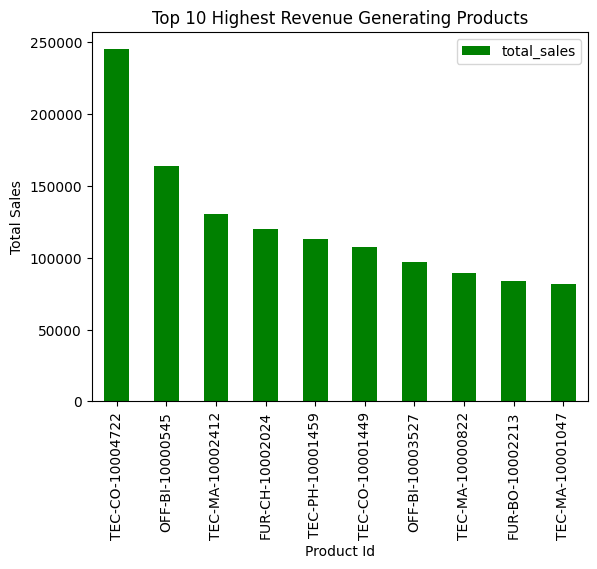

In [20]:
question1.plot(
    x = "product_id",
    y = "total_sales",
    kind = 'bar',
    color = 'green'
)
plt.title("Top 10 Highest Revenue Generating Products")
plt.xlabel("Product Id")
plt.ylabel("Total Sales")
plt.savefig("01_Top_10_Highest_Revenue_Generating_Products.png")
plt.show()

### 2. Find Top 5 Highest Selling Products in each Region?

In [21]:
query = """
    with CTE as
    (
        select 
            product_id,
            region,
            sum(sales_price) as total_sales,
            dense_rank() over (partition by region order by sum(sales_price) desc) as D_Rank
        from orders
        group by product_id, region
        order by region
    )
    select * 
    from cte
    where D_Rank <= 5
"""

question2 = pd.read_sql(query, engine)
question2


,product_id,region,total_sales,D_Rank
0,OFF-BI-10000545,Central,125827.5,1
1,TEC-CO-10004722,Central,84875.0,2
2,TEC-MA-10000822,Central,77509.8,3
3,OFF-BI-10001120,Central,55282.5,4
4,OFF-BI-10004995,Central,42210.0,5
5,TEC-CO-10004722,East,106421.0,1
6,TEC-MA-10001047,East,81549.0,2
7,FUR-BO-10004834,East,66364.2,3
8,TEC-CO-10001449,East,60948.0,4
9,FUR-CH-10002024,East,60189.6,5


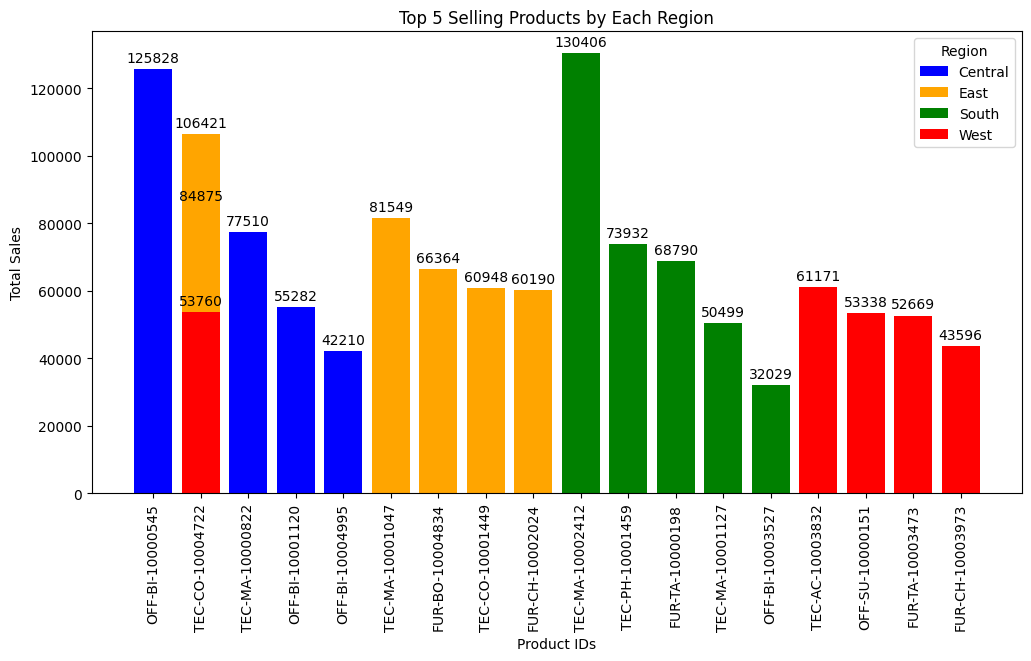

In [22]:
colors = {
    'Central' : 'blue',
    'East'    : 'orange',
    'South'   : 'green',
    'West'    : 'red'
}

plt.figure(figsize= (12,6))

for region in question2['region'].unique():

    region_data = question2[question2['region'] == region]

    bars = plt.bar(
        region_data['product_id'],
        region_data['total_sales'],
        color = colors[region],
        label = region
    )

    plt.bar_label(
        bars,
        fmt= '%.0f',
        padding = 3
    )

plt.title("Top 5 Selling Products by Each Region"),
plt.xlabel("Product IDs"),
plt.ylabel("Total Sales"),
plt.legend(title = 'Region')
plt.xticks(rotation = 90)
plt.savefig("02_Top_5_Selling_Products_by_Each_Region.png")
plt.show()

### 3. Find State wise and City wise Count of Orders

In [23]:
query = """
select
    state as order_state,
    city as order_city,
    count(order_id) as No_of_orders
from orders
group by order_state, order_city
order by order_state, order_city
"""

question3 = pd.read_sql(query, engine)
question3

,order_state,order_city,No_of_orders
0,Alabama,Auburn,6
1,Alabama,Decatur,13
2,Alabama,Florence,5
3,Alabama,Hoover,4
4,Alabama,Huntsville,10
...,...,...,...
599,Wisconsin,Superior,9
600,Wisconsin,Waukesha,1
601,Wisconsin,Wausau,4
602,Wisconsin,West Allis,2


### 4. Which Category has the Highest Selling Price?

In [24]:
query = """
    select
        category,
        sum(sales_price) as total_sales
    from orders
    group by category
    order by total_sales desc
"""

question4 = pd.read_sql(query, engine)
question4

,category,total_sales
0,Technology,3934910.7
1,Furniture,3720742.4
2,Office Supplies,3423675.1


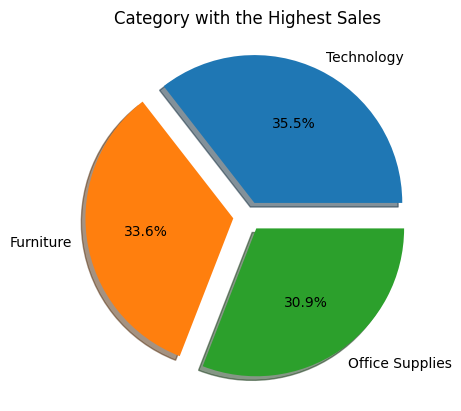

In [25]:
plt.pie(
    question4['total_sales'],
    labels = question4['category'],
    autopct= "%1.1f%%",
    explode= [0.1,0.1,0.1],
    shadow= True
)

plt.title("Category with the Highest Sales")
plt.savefig("03_Category_with_the_Highest_Sales.png")
plt.show()

### 5. Which Sub_Category has the highest Profit?

In [26]:
query = """
    select
        sub_category,
        sum(profit) as total_profit
    from orders
    group by sub_category
    order by total_profit desc
    limit 10
"""

question5 = pd.read_sql(query, engine)
question5

,sub_category,total_profit
0,Chairs,29815.1
1,Phones,28368.3
2,Storage,19538.0
3,Binders,19208.6
4,Tables,18591.2
5,Machines,18121.7
6,Accessories,15444.6
7,Copiers,14498.9
8,Bookcases,10496.1
9,Appliances,10267.7


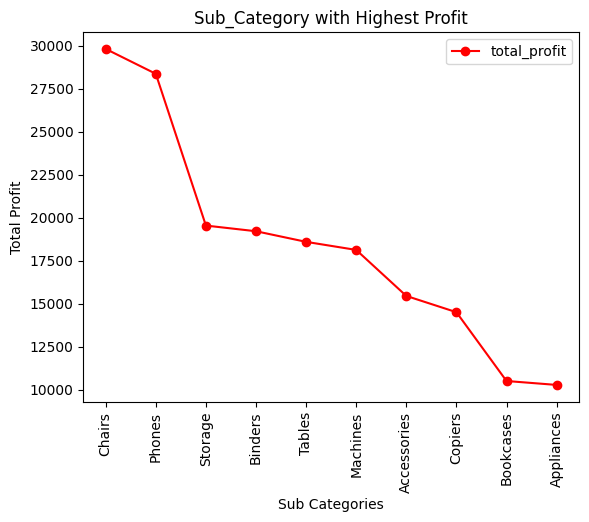

In [27]:
plt.Figure(figsize= (18,9))

ax = question5.plot(
    x = 'sub_category',
    y = 'total_profit',
    kind = 'line',
    color = 'red',
    marker = 'o'
)

plt.title('Sub_Category with Highest Profit'),
plt.xlabel('Sub Categories'),
plt.ylabel('Total Profit')

# for showing all the labels in the x-axis

ax.set_xticks(range(len(question5['sub_category'])))
ax.set_xticklabels(question5['sub_category'], rotation = 90)
plt.savefig("04_Sub_Category_with_Highest_Profit.png")
plt.show()

### 6. Which Quarter is the Best Performing at all time?

In [28]:
query = """
    select
        concat('Q',quarter) as order_quarter,
        sum(sales_price) as total_sales
    from orders
    group by order_quarter
    order by total_sales
"""

question6 = pd.read_sql(query, engine)
question6

,order_quarter,total_sales
0,Q2,2638205.1
1,Q3,2651892.3
2,Q1,2835003.8
3,Q4,2954227.0


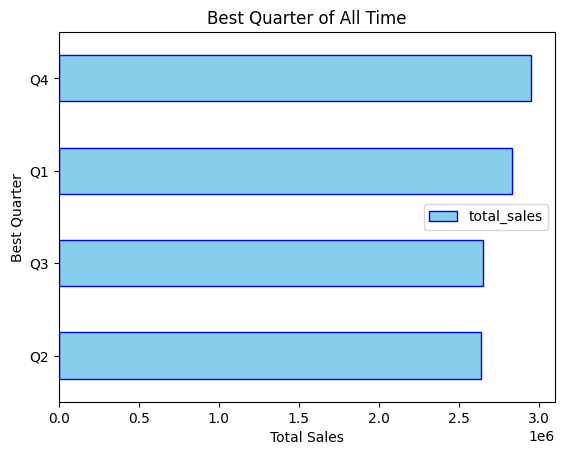

In [29]:
question6.plot(
    x = 'order_quarter',
    y = 'total_sales',
    kind = 'barh',
    color = 'skyblue',
    edgecolor = 'blue'
)
plt.title("Best Quarter of All Time")
plt.xlabel("Total Sales")
plt.ylabel("Best Quarter")
plt.savefig("05_Best_Quarter_Of_All_Time.png")
plt.show()

### 7. Find month over month growth comparison for 2022 and 2023 sales eg: jan 2022 vs jan 2023?

In [30]:
query = """
    with CTE as
    (
        select
            year as order_year,
            month as order_month,
            month_name as order_month_name,
            sum(sales_price) as total_sales
        from orders
        group by order_year, order_month, order_month_name
    )
        select
            order_month,
            order_month_name,
            sum(case when order_year = 2022 then total_sales else 0 end) as Year_2022,
            sum(case when order_year = 2023 then total_sales else 0 end) as Year_2023,
            concat(
            round(
            (
                sum(case when order_year = 2023 then total_sales else 0 end)
                -
                sum(case when order_year = 2022 then total_sales else 0 end)
            )
            /
            sum(case when order_year = 2022 then total_sales else 0 end)*100,2),'%%') as 'percent_growth'
        from CTE
        group by order_month, order_month_name
        order by order_month, order_month_name
"""
question7 = pd.read_sql(query, engine)
question7

,order_month,order_month_name,Year_2022,Year_2023,percent_growth
0,1,January,437431.3,434765.5,-0.61%
1,2,February,444011.1,731638.8,64.78%
2,3,March,394105.2,393051.9,-0.27%
3,4,April,476400.9,543231.5,14.03%
4,5,May,413625.5,410707.9,-0.71%
5,6,June,465300.3,328939.0,-29.31%
6,7,July,375278.4,422533.7,12.59%
7,8,August,534562.4,465010.3,-13.01%
8,9,September,433887.0,420620.5,-3.06%
9,10,October,601707.8,626498.3,4.12%


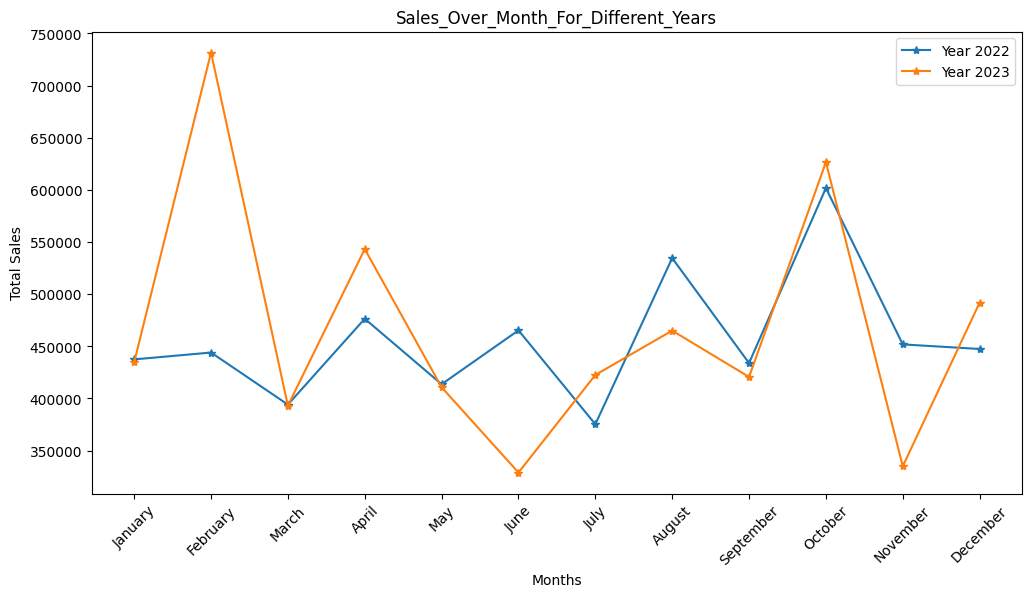

In [31]:
plt.figure(figsize= (12,6))

plt.plot(question7['order_month_name'], question7['Year_2022'], marker = '*', label = 'Year 2022') 
plt.plot(question7['order_month_name'], question7['Year_2023'], marker = '*', label = 'Year 2023')

plt.xticks(rotation = 45)
plt.legend()
plt.title("Sales_Over_Month_For_Different_Years")
plt.xlabel("Months")
plt.ylabel("Total Sales")
plt.savefig("06_Sales_Over_Month_For_Different_Years.png")
plt.show()

### 8. For each category which month has the highest sales?

In [32]:
query = """
    with CTE as
    (
        select
            category,
            year as order_year,
            month as order_month,
            month_name as order_month_name,
            sum(sales_price) as total_sales
        from orders
        group by category, order_year, order_month, order_month_name
    )
    select * from
    (
    select
        *,
        dense_rank() over (partition by category order by total_sales desc) as D_rank
    from CTE
    ) as t1
    where D_rank = 1
"""

question8 = pd.read_sql(query, engine)
question8

,category,order_year,order_month,order_month_name,total_sales,D_rank
0,Furniture,2023,8,August,230523.5,1
1,Office Supplies,2023,2,February,287244.6,1
2,Technology,2023,10,October,295586.5,1


[]

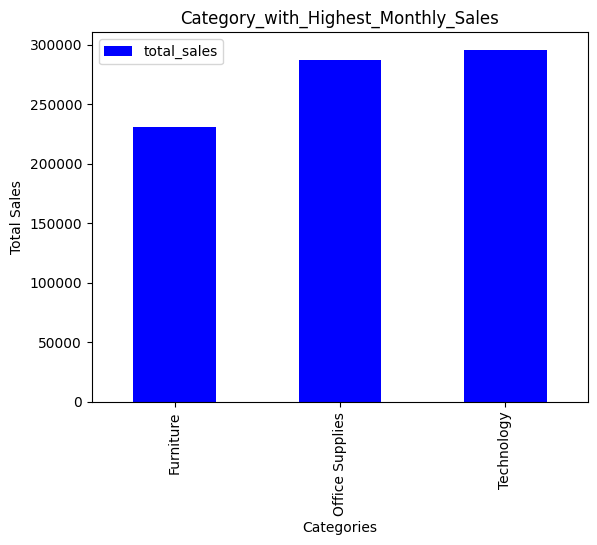

In [33]:
question8.plot(
    x = 'category',
    y = 'total_sales',
    color = 'blue',
    kind = 'bar'
)

plt.title("Category_with_Highest_Monthly_Sales")
plt.xlabel("Categories")
plt.ylabel("Total Sales")
plt.savefig("07_Category_with_Highest_Monthly_Sales.png")
plt.plot()

### 9. Which sub-category had highest growth by profit in 2023 compare to 2022?

In [34]:
query = """
    with CTE as
    (
        select
            sub_category,
            year as order_year,
            sum(profit) as total_profit
        from orders
        group by sub_category, order_year
    ),
    growth_CTE as
    (
        select
            sub_category,
            sum(case when order_year = 2022 then total_profit else 0 end) as Year_2022,
            sum(case when order_year = 2023 then total_profit else 0 end) as Year_2023,
            round(
            (
                sum(case when order_year = 2023 then total_profit else 0 end)
                -
                sum(case when order_year = 2022 then total_profit else 0 end)
            )
            /
            sum(case when order_year = 2022 then total_profit else 0 end)*100,2) as growth_percent
        from CTE
        group by sub_category
    )
    select
        sub_category,
        Year_2022,
        Year_2023,
        growth_percent
    from growth_CTE
    group by sub_category
    order by growth_percent desc
"""

question9 = pd.read_sql(query, engine)
question9

,sub_category,Year_2022,Year_2023,growth_percent
0,Machines,7243.2,10878.5,50.19
1,Supplies,1500.7,1937.4,29.10
2,Binders,8685.5,10523.1,21.16
3,Storage,8907.4,10630.6,19.35
4,Phones,13024.7,15343.6,17.80
5,Accessories,7387.2,8057.4,9.07
6,Envelopes,607.2,640.0,5.40
7,Chairs,14725.3,15089.8,2.48
8,Art,924.1,935.7,1.26
9,Paper,3058.9,2942.4,-3.81


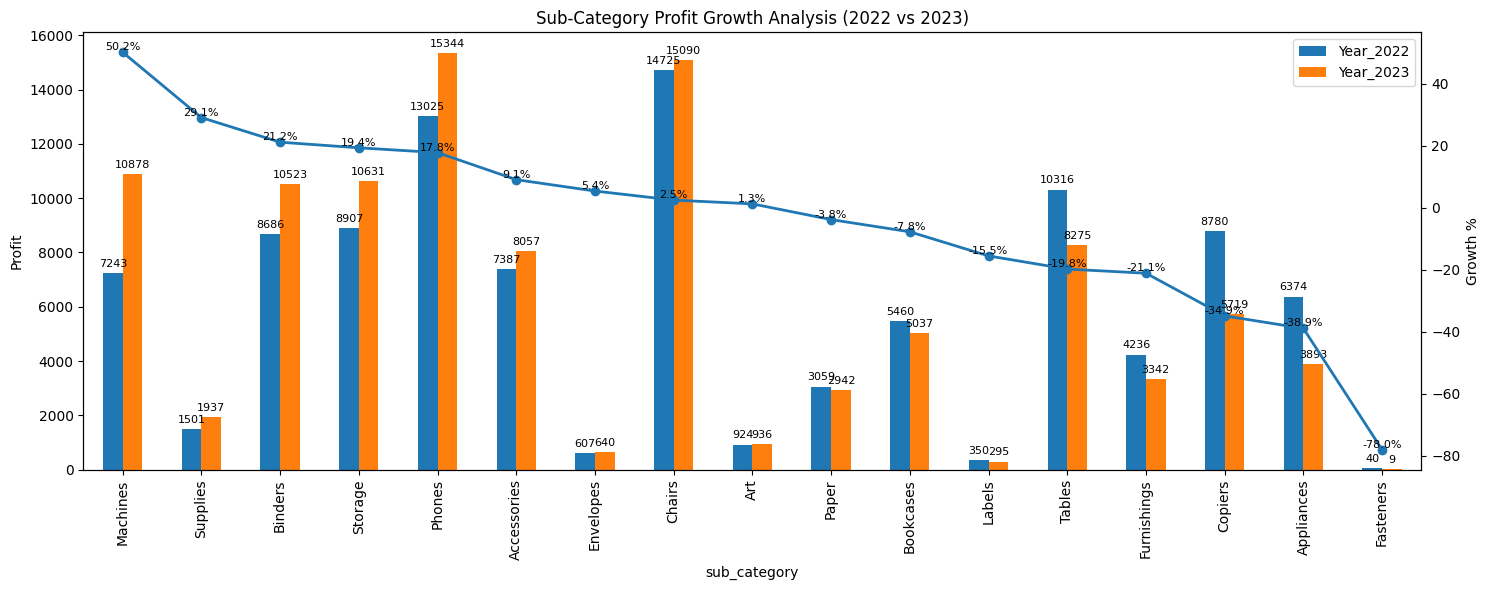

In [37]:
fig, ax1 = plt.subplots(figsize=(15,6))

question9.plot(
    x='sub_category',
    y=['Year_2022', 'Year_2023'],
    kind='bar',
    ax=ax1
)

for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt = '%.0f',
        padding = 3,
        fontsize = 8
    )

ax1.set_ylabel('Profit')

# Secondary Axis for Growth %
ax2 = ax1.twinx()

ax2.plot(
    range(len(question9)),
    question9['growth_percent'],
    marker='o',
    linewidth=2,
    label = 'Growth %'
)

# Add labels on Growth % Points

for i, value in enumerate(question9['growth_percent']):
    ax2.text(
        i,
        value,
        f'{value:.1f}%',
        ha = 'center',
        va = 'bottom',
        fontsize = 8
    )

ax2.set_ylabel('Growth %')

plt.title('Sub-Category Profit Growth Analysis (2022 vs 2023)')
plt.xlabel('Sub Category')
plt.xticks(rotation=45)
plt.savefig("08_Sub-Category Profit Growth Analysis (2022 vs 2023).jpg")

plt.tight_layout()
plt.show()